# Agrupamento de Dados

Técnica computacional que visa separar objetos em grupos, baseando-se nas características destes objetos.

A ideia básica consiste em colocar em um mesmo grupo objetos similares de acordo com algum critério pré-determinado.

O critério baseia-se normalmente em uma função de dissimilaridade ou densidade.

Os grupos determinados por uma métrica de qualidade devem apresentar alta homogeneidade interna e alta separação (heterogeneidade externa).

Os elementos de um determinado grupo devem ser mutuamente similares e, preferencialmente, muito diferentes dos elementos de outros grupos.

## Processo de Agrupamento

Dado um conjunto de dados e o número (estimado) de grupos existentes, o objetivo é encontrar uma partição dos dados em grupos tal que:

- Amostras intragrupos são mais similares
- Amostras intergrupos são menos similares

A ideia de similaridade é formulada matematicamente a partir de uma medida de distância.

Cada grupo possui um protótipo que o representa, por exemplo, o centro do grupo.

As distâncias são medidas a partir deste protótipo.

## Agrupamento - Exemplo

Considere os elementos identificados pelo conjunto:

S = {1, 2, 3, 4, 5, 6, 7, 8, 9}

Considere uma função de distância d : S × S → ℝ tal que, para todo i, j pertencente a S:
- d(i, j) ≥ 0
- d(i, j) = 0, se i = j
- d(i, j) = d(j, i)

Uma função de agrupamento f é uma função que recebe d e retorna uma partição Γ de S.

### Exemplo de Partição

Γ = {{1, 2, 3}, {4, 5, 6}, {7, 8, 9}}

Neste caso há três grupos:
- Grupo 1 = {1, 2, 3}
- Grupo 2 = {4, 5, 6}
- Grupo 3 = {7, 8, 9}

A seguir, um gráfico ilustrando a separação dos grupos.

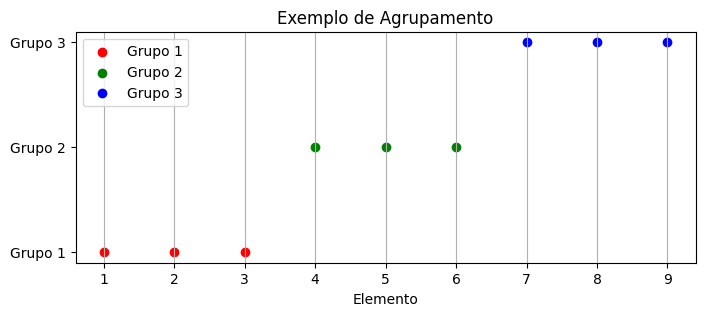

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Definindo os grupos
grupo1 = [1, 2, 3]
grupo2 = [4, 5, 6]
grupo3 = [7, 8, 9]

# Para visualização, vamos posicionar cada grupo em uma linha diferente
y1 = [1]*len(grupo1)
y2 = [2]*len(grupo2)
y3 = [3]*len(grupo3)

plt.figure(figsize=(8, 3))
plt.scatter(grupo1, y1, color='red', label='Grupo 1')
plt.scatter(grupo2, y2, color='green', label='Grupo 2')
plt.scatter(grupo3, y3, color='blue', label='Grupo 3')

plt.yticks([1, 2, 3], ['Grupo 1', 'Grupo 2', 'Grupo 3'])
plt.xlabel('Elemento')
plt.title('Exemplo de Agrupamento')
plt.legend()
plt.grid(axis='x')
plt.show()

## Tipos de Aprendizado

Algoritmos de aprendizado para agrupamento particionam o conjunto de dados em grupos através de alguma medida de similaridade ou densidade.

- **Supervisionado:** O modelo aprende a partir de exemplos rotulados, ou seja, cada amostra de treinamento já pertence a um grupo conhecido.
- **Não-Supervisionado:** O modelo não recebe rótulos e deve identificar padrões ou grupos nos dados apenas com base nas características e relações entre as amostras.

O agrupamento é uma técnica típica de aprendizado não-supervisionado.

## Principais Métodos de Agrupamento

- **Agrupamento Hierárquico:** Constrói uma hierarquia de grupos, podendo ser aglomerativo (bottom-up) ou divisivo (top-down).
- **Agrupamento por Partição:** Divide o conjunto de dados em um número fixo de grupos, otimizando uma função objetivo.
- **C-Means (K-Means):** Algoritmo de partição que busca minimizar a soma das distâncias quadráticas entre os pontos e o centro do grupo.
- **Fuzzy C-Means:** Variante do C-Means onde cada ponto pode pertencer a mais de um grupo, com graus de pertinência.
- **Gustafson-Kessel:** Extensão do Fuzzy C-Means que permite grupos de formatos elípticos, adaptando a métrica de distância.
- **Mountain:** Método baseado em densidade, identifica centros de grupos em regiões de alta densidade de dados.
- **Subtrativo:** Variante do Mountain, eficiente para grandes conjuntos de dados, identifica protótipos de grupos por densidade local.

### Agrupamento Hierárquico

Organiza o conjunto de dados em forma de árvore binária, permitindo que cada grupo contenha subgrupos.

A árvore é visualizada sob a forma de um dendograma, cuja raiz é um grupo aglomerando todos os elementos do conjunto de dados e as folhas são cada elemento separadamente.

A seguir, um exemplo de dendograma para o conjunto S = {1, 2, 3, 4, 5, 6, 7, 8, 9}.

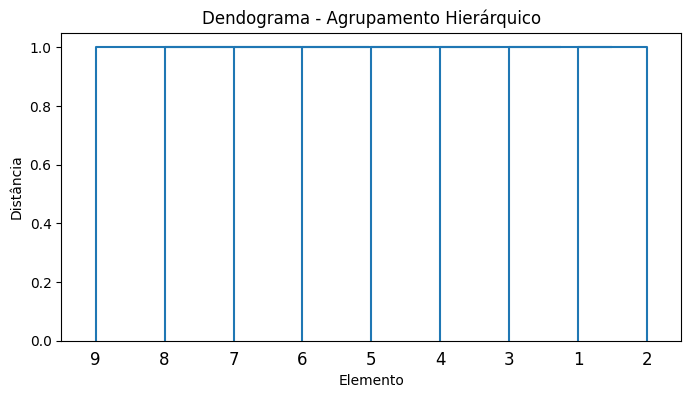

In [2]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Conjunto de dados S
S = np.array([[i] for i in range(1, 10)])

# Realiza o agrupamento hierárquico (método 'single')
Z = linkage(S, method='single')

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=[str(i) for i in range(1, 10)])
plt.title('Dendograma - Agrupamento Hierárquico')
plt.xlabel('Elemento')
plt.ylabel('Distância')
plt.show()

### Agrupamento por Partição

Associa um conjunto de dados a grupos, sendo que na versão tradicional, cada entidade é associada a somente um grupo.

As associações são feitas com base nas características do conjunto de dados, buscando reunir em um mesmo grupo as entidades que possuam maiores semelhanças entre si.

O resultado final é a divisão do conjunto de dados em vários subgrupos, que correspondem aos grupos descobertos.

No agrupamento por partição não é criada uma estrutura hierárquica.

### Agrupamento Tradicional (Crisp) vs Agrupamento Fuzzy

**Agrupamento Tradicional (Crisp):**
- Cada padrão pertence a um único grupo
- Grupos são disjuntos
- Fronteira de decisão abrupta {0, 1}

**Agrupamento Fuzzy:**
- Estende a noção de associatividade de cada padrão aos grupos utilizando o conceito da função de pertinência
- Cada padrão possui um grau de pertinência para cada grupo
- Fronteira de decisão suave [0, 1]

### Exemplo: Partição Crisp vs Partição Fuzzy

Vamos considerar o conjunto S = {1, 2, 3, 4, 5, 6, 7, 8, 9} e a partição em três grupos.

- **Partição Crisp:** Cada elemento pertence a apenas um grupo.
- **Partição Fuzzy:** Cada elemento pode pertencer a mais de um grupo, com diferentes graus de pertinência.

A seguir, exemplos ilustrativos das duas abordagens.

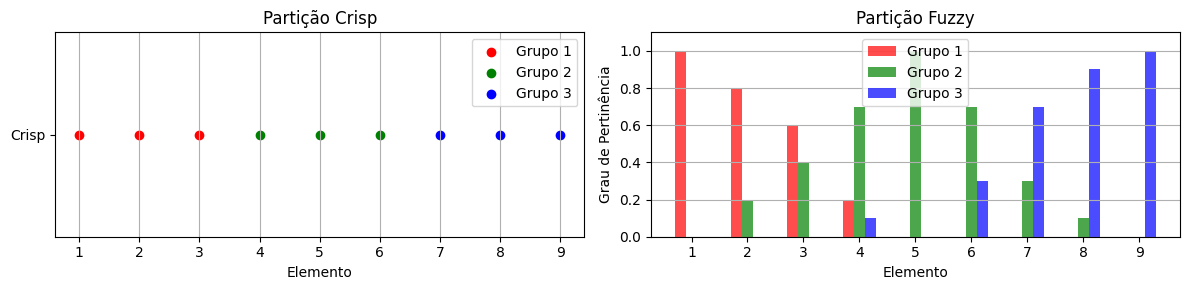

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Elementos
S = np.arange(1, 10)

# Partição Crisp
crisp_labels = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])  # 3 grupos

# Partição Fuzzy (graus de pertinência para cada grupo)
fuzzy_membership = np.array([
    [1, 0, 0],   # 1
    [0.8, 0.2, 0], # 2
    [0.6, 0.4, 0], # 3
    [0.2, 0.7, 0.1], # 4
    [0, 1, 0],   # 5
    [0, 0.7, 0.3], # 6
    [0, 0.3, 0.7], # 7
    [0, 0.1, 0.9], # 8
    [0, 0, 1]    # 9
])

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

# Plot Crisp
colors = ['red', 'green', 'blue']
for g in range(3):
    axs[0].scatter(S[crisp_labels == g], [1]*sum(crisp_labels == g), color=colors[g], label=f'Grupo {g+1}')
axs[0].set_yticks([1])
axs[0].set_yticklabels(['Crisp'])
axs[0].set_xlabel('Elemento')
axs[0].set_title('Partição Crisp')
axs[0].legend()
axs[0].grid(axis='x')

# Plot Fuzzy
for g in range(3):
    axs[1].bar(S-0.2+0.2*g, fuzzy_membership[:, g], width=0.2, color=colors[g], alpha=0.7, label=f'Grupo {g+1}')
axs[1].set_xticks(S)
axs[1].set_xlabel('Elemento')
axs[1].set_ylabel('Grau de Pertinência')
axs[1].set_title('Partição Fuzzy')
axs[1].set_ylim(0, 1.1)
axs[1].legend()
axs[1].grid(axis='y')

plt.tight_layout()
plt.show()

## Aplicações de Técnicas de Agrupamento

- Reconhecimento de padrões
- Detecção de spam
- Classificação do perfil de usuários
- Processamento de imagens
- Identificação de sistemas dinâmicos
- Diagnóstico médico
- Análise de risco financeiro
- Organização e categorização de dados
- Compressão de dados
- Construção de modelos
- ...

### Aplicações: Construção de Modelos Fuzzy

- **Início:** Tradicionalmente, as regras dos modelos fuzzy eram geradas por um especialista.
- **Atual:** As regras podem ser definidas com base em informações extraídas de um conjunto de dados.
- Utilizam-se informações sobre a organização espacial das variáveis de entrada e/ou saída para a definição do conjunto de regras.
- Informações sobre o erro de modelagem, calculado recursivamente, também podem ser usadas para a construção do conjunto de regras.

O agrupamento auxilia na identificação de padrões e regiões relevantes nos dados, facilitando a geração automática de regras para sistemas fuzzy.

# Curva ROC, TVP, TFP, Especificidade e AUC

A curva ROC (Receiver Operating Characteristic) compara os benefícios de uma classificação correta (Taxa de Verdadeiros Positivos - TVP ou Sensibilidade) com o custo de uma classificação incorreta (Taxa de Falsos Positivos - TFP, também conhecida como 1 - Especificidade).

- **TVP (Sensibilidade):** Proporção de positivos corretamente classificados.
- **TFP:** Proporção de negativos classificados incorretamente como positivos.
- **Especificidade:** Proporção de negativos corretamente classificados (Especificidade = VN / (VN + FP)).
- **AUC (Area Under the ROC Curve):** Mede a área sob a curva ROC. Quanto mais próximo de 1, melhor o desempenho do classificador.

A curva ROC é útil para comparar classificadores e avaliar o desempenho em diferentes limiares de decisão.

### Agrupamento por Partição Crisp — Restrições

Dado um conjunto de dados $X = \{x_1, \ldots, x_i, \ldots, x_n\}$, onde $x_i = (x_{i1}, \ldots, x_{ip}) \in \mathbb{R}^p$:

O objetivo é encontrar um conjunto de $c$ grupos, $C = \{C_1, \ldots, C_k, \ldots, C_c\}$ ($c \leq n$) tal que:

- $C_k \neq \emptyset$, para $k = 1, \ldots, c$ (nenhum grupo vazio)
- $\bigcup_{k=1}^c C_k = X$ (todos os elementos são agrupados)
- $C_k \cap C_q = \emptyset$, para $k, q = 1, \ldots, c$, $k \neq q$ (os grupos são disjuntos)

Essas restrições garantem que cada elemento pertence a um único grupo e todos os elementos são agrupados.

### Exemplo — C-Means (K-Means)

1. Selecionamos $c$ pontos aleatórios (por exemplo, $c = 3$) no espaço de dados, chamados de centróides ou protótipos.
2. Para cada entidade (ponto do conjunto de dados), calculamos o centróide mais próximo e associamos esse objeto a tal centróide (formando os grupos iniciais).

A seguir, um exemplo ilustrativo dessas etapas.

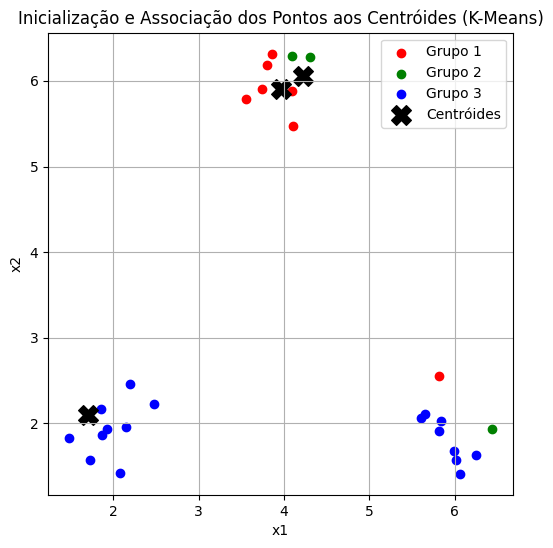

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Gerar dados 2D simples
np.random.seed(42)
X = np.vstack([
    np.random.normal([2, 2], 0.3, (10, 2)),
    np.random.normal([6, 2], 0.3, (10, 2)),
    np.random.normal([4, 6], 0.3, (10, 2))
])

# Inicializar 3 centróides aleatórios
c = 3
centroids = X[np.random.choice(X.shape[0], c, replace=False)]

# Associar cada ponto ao centróide mais próximo
from scipy.spatial.distance import cdist
labels = np.argmin(cdist(X, centroids), axis=1)

# Plotar
colors = ['red', 'green', 'blue']
plt.figure(figsize=(6, 6))
for i in range(c):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], color=colors[i], label=f'Grupo {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centróides')
plt.title('Inicialização e Associação dos Pontos aos Centróides (K-Means)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

3. Recalculamos a posição dos centróides com base na posição dos objetos associados a cada um deles.
4. Para recalcular a posição de um centróide, considera-se a média das posições dos objetos relacionados (média aritmética).
5. Ao final, obtemos as novas coordenadas dos centróides que particionam o espaço.

A seguir, um exemplo ilustrando a atualização dos centróides após uma iteração.

# Curva ROC, TVP, TFP, Especificidade e AUC

A curva ROC (Receiver Operating Characteristic) compara os benefícios de uma classificação correta (Taxa de Verdadeiros Positivos - TVP ou Sensibilidade) com o custo de uma classificação incorreta (Taxa de Falsos Positivos - TFP, também conhecida como 1 - Especificidade).

- **TVP (Sensibilidade):** Proporção de positivos corretamente classificados.
- **TFP:** Proporção de negativos classificados incorretamente como positivos.
- **Especificidade:** Proporção de negativos corretamente classificados (Especificidade = VN / (VN + FP)).
- **AUC (Area Under the ROC Curve):** Mede a área sob a curva ROC. Quanto mais próximo de 1, melhor o desempenho do classificador.

A curva ROC é útil para comparar classificadores e avaliar o desempenho em diferentes limiares de decisão.

In [5]:
# Atualizar centróides: calcular a média dos pontos de cada grupo
new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(c)])

# Associar novamente cada ponto ao novo centróide mais próximo
ew_labels = np.argmin(cdist(X, new_centroids), axis=1)

# Plotar
plt.figure(figsize=(6, 6))
for i in range(c):
    plt.scatter(X[new_labels == i, 0], X[new_labels == i, 1], color=colors[i], label=f'Grupo {i+1}')
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], color='black', marker='X', s=200, label='Novos centróides')
plt.title('Atualização dos Centróides (K-Means)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'new_labels' is not defined

<Figure size 600x600 with 0 Axes>

### Algoritmo do C-Means (K-Means)

1. **Inicialize os centros dos grupos** (centróides).
2. **Determine a matriz de pertinência** (associação de cada entidade ao grupo mais próximo).
3. **Calcule a função de custo** (por exemplo, a soma das distâncias quadráticas entre os pontos e seus centróides).
4. **Atualize os centros dos grupos** (recalcule os centróides com base nos objetos associados).
5. **Repita os passos 2, 3 e 4** até que alguma condição de parada seja atingida:
   - Número máximo de iterações;
   - Nenhuma entidade muda de grupo;
   - Porcentagem de entidades que alteram de grupo é menor que um limiar pré-definido, etc.

### Aplicação do C-Means e Agrupamento por Partição Fuzzy

- Implementações clássicas: `cmeans.m` (fuzzy c-means), `kmeans1.m` (k-means tradicional).

#### Agrupamento por Partição Fuzzy

- Permite lidar com incertezas presentes em diversas situações.
- As partições resultantes desses algoritmos associam a cada entidade um grau de pertinência a cada grupo, no intervalo [0, 1].
- Um valor maior indica maior pertinência ao grupo.
- Quanto mais próxima (ou distante) uma entidade estiver do protótipo de um grupo, maior (ou menor) será seu grau de pertinência a esse grupo.

### Fuzzy C-Means — Restrições

Dado um conjunto de $n$ padrões $X = \{x_1, x_2, \ldots, x_n\}$, onde $x_i$ é um padrão $d$-dimensional:

- Um agrupamento fuzzy é uma coleção de $k$ grupos $c_1, c_2, \ldots, c_k$ e uma matriz de partição $U = [u_{i,j}]$ com $u_{i,j} \in [0, 1]$, para $i = 1, \ldots, n$ e $j = 1, \ldots, k$.
- Cada elemento $u_{i,j}$ representa o grau de pertinência do padrão $i$ ao grupo $c_j$.
- A soma dos graus de pertinência de um padrão em todos os grupos deve ser igual a 1:
  $$\sum_{j=1}^k u_{i,j} = 1, \quad \forall i$$
- Cada grupo contém pelo menos um ponto com grau de pertinência maior que zero e não contém todos os pontos com grau de pertinência unitário:
  $$0 < \sum_{i=1}^n u_{i,j} < n, \quad \forall j$$

Essas restrições garantem a flexibilidade e a suavidade das fronteiras entre os grupos no Fuzzy C-Means.

### Fuzzy C-Means — Função de Custo e Atualizações

- O Fuzzy C-Means otimiza a seguinte função de custo:
  $$J = \sum_{j=1}^k \sum_{i=1}^n u_{ij}^m \|c_j - x_i\|^2$$
  onde $m \in [1, \infty)$ é o expoente de ponderação que determina a influência dos pesos.

- **Cálculo dos centros (protótipos):**
  $$c_j = \frac{\sum_{i=1}^n u_{ij}^m x_i}{\sum_{i=1}^n u_{ij}^m}$$
  Ou seja, a média ponderada de todos os padrões pelo grau de pertinência ao grupo $j$.

- **Atualização da matriz de partição:**
  $$u_{ij} = \frac{1}{\sum_{k=1}^c \left(\frac{d_{ij}}{d_{kj}}\right)^{2/(m-1)}}$$
  onde $d_{ij} = \|x_i - c_j\|$.

- O valor da pertinência $u_{ij}$ é alto se o ponto $i$ está próximo do centro $j$.
- Se o ponto coincide com o centro de um grupo ($x_i = c_j$), então $u_{ij} = 1$ e $u_{il} = 0$ para $l \neq j$.

### Fuzzy C-Means — Função de Custo e Atualizações

- O Fuzzy C-Means otimiza a seguinte função de custo:
  $$J = \sum_{j=1}^k \sum_{i=1}^n u_{ij}^m \|c_j - x_i\|^2$$
  onde $m \in [1, \infty)$ é o expoente de ponderação que determina a influência dos pesos.

- **Cálculo dos centros (protótipos):**
  $$c_j = \frac{\sum_{i=1}^n u_{ij}^m x_i}{\sum_{i=1}^n u_{ij}^m}$$
  Ou seja, a média ponderada de todos os padrões pelo grau de pertinência ao grupo $j$.

- **Atualização da matriz de partição:**
  $$u_{ij} = \frac{1}{\sum_{k=1}^c \left(\frac{d_{ij}}{d_{kj}}\right)^{2/(m-1)}}$$
  onde $d_{ij} = \|x_i - c_j\|$.

- O valor da pertinência $u_{ij}$ é alto se o ponto $i$ está próximo do centro $j$.
- Se o ponto coincide com o centro de um grupo ($x_i = c_j$), então $u_{ij} = 1$ e $u_{il} = 0$ para $l \neq j$.

### Algoritmo do Fuzzy C-Means

1. **Inicialize a matriz de pertinência** (partição inicial) $U$ com valores aleatórios entre 0 e 1, de forma que $\sum_{i=1}^c u_{ij} = 1$, $\forall j = 1, \ldots, n$.
2. **Calcule o centro de cada grupo** $c_i$ utilizando a matriz de partição.
3. **Calcule a função de custo**.
4. **Verifique o critério de convergência** (por exemplo, mudança mínima nos centros ou número máximo de iterações).
5. **Atualize a matriz de partição** $U$.
6. **Repita** os passos 2 a 5 até que o critério de parada seja atingido.

## Exemplo Prático: Fuzzy C-Means em Python

Vamos aplicar o algoritmo Fuzzy C-Means a um conjunto de dados simples, visualizar os resultados e comparar com o K-Means tradicional.

Utilizaremos a biblioteca `scikit-fuzzy`, que implementa o Fuzzy C-Means de forma eficiente e didática.

> **Dica:** O clássico `fcm.m` do MATLAB é uma referência tradicional para implementação do Fuzzy C-Means. Em Python, a função equivalente é `skfuzzy.cmeans`.

In [ ]:
# Instale a biblioteca scikit-fuzzy, se necessário
# !pip install scikit-fuzzy

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# Gerar dados 2D simples (mesmo padrão do exemplo do K-Means)
np.random.seed(42)
X = np.vstack([
    np.random.normal([2, 2], 0.3, (10, 2)),
    np.random.normal([6, 2], 0.3, (10, 2)),
    np.random.normal([4, 6], 0.3, (10, 2))
]).T  # Transpor para shape (features, samples)

# Parâmetros do Fuzzy C-Means
n_clusters = 3
m = 2.0  # Expoente de fuzzificação

# Executar Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None, seed=42
)

# Para cada ponto, o grupo de maior pertinência
labels_fuzzy = np.argmax(u, axis=0)

# Visualização dos clusters fuzzy
colors = ['red', 'green', 'blue']
plt.figure(figsize=(7, 6))
for i in range(n_clusters):
    plt.scatter(X[0, labels_fuzzy == i], X[1, labels_fuzzy == i], color=colors[i], label=f'Grupo {i+1}')
    # Visualizar centros
    plt.scatter(cntr[i, 0], cntr[i, 1], color=colors[i], marker='X', s=200, edgecolor='black')
plt.title('Agrupamento Fuzzy C-Means')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

### Comparação: K-Means vs Fuzzy C-Means

No Fuzzy C-Means, cada ponto possui um grau de pertinência para cada grupo. A seguir, visualizamos a matriz de pertinência para os três clusters:

- Cada linha representa um cluster.
- Cada coluna representa um ponto de dado.
- Os valores indicam o grau de pertinência (quanto mais próximo de 1, maior a associação ao grupo).

Observe que, diferente do K-Means, os pontos próximos às fronteiras dos clusters apresentam pertinências intermediárias.

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 3))
sns.heatmap(u, cmap='viridis', annot=False, cbar=True)
plt.xlabel('Índice do Ponto')
plt.ylabel('Cluster')
plt.title('Matriz de Pertinência (Fuzzy C-Means)')
plt.show()

### Observações Práticas

- O Fuzzy C-Means é sensível à inicialização dos centros, assim como o K-Means.
- Recomenda-se executar o algoritmo várias vezes com diferentes inicializações e escolher a solução com melhor desempenho (maior FPC — Fuzzy Partition Coefficient).
- O número de clusters deve ser definido previamente e influencia fortemente o resultado.
- O Fuzzy C-Means é especialmente útil quando há sobreposição entre grupos ou incerteza na associação dos dados.

**Vantagens:**
- Algoritmo de cluster fuzzy mais utilizado;
- Implementação simples;
- Computacionalmente rápido e eficiente;
- Convergência mais rápida que o C-Means.

**Desvantagens:**
- Número de clusters a serem encontrados é um parâmetro de entrada e afeta muito os resultados obtidos;
- Os resultados são dependentes da posição dos centros;
- Uma má inicialização dos protótipos pode levar a uma convergência para mínimos locais, não obtendo a melhor estrutura do agrupamento;
- É aconselhável executar o algoritmo várias vezes, cada uma com um conjunto diferente de centros iniciais.

> **Referência:** Para mais detalhes e implementações clássicas, consulte o arquivo `fcm.m` (MATLAB) ou a documentação do [scikit-fuzzy](https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_cmeans.html).

## Algoritmo Gustafson-Kessel (GK)

O algoritmo Gustafson-Kessel é uma extensão do Fuzzy C-Means que permite identificar grupos com formatos geométricos diferentes (não apenas esféricos), adaptando a métrica de distância para cada cluster.

- Utiliza uma **medida de distância adaptativa** baseada na distância de Mahalanobis, permitindo que cada grupo tenha sua própria forma e orientação.
- É especialmente útil quando os dados apresentam clusters elípticos ou com diferentes dispersões.

### Função Objetivo
A função objetivo do GK é semelhante à do Fuzzy C-Means, mas utiliza a distância de Mahalanobis:

$$
J = \sum_{i=1}^c \sum_{k=1}^n \mu_{ik}^m \; d_{A_i}^2(x_k, v_i)
$$

onde:
- $d_{A_i}^2(x_k, v_i) = (x_k - v_i)^T A_i (x_k - v_i)$ é a distância de Mahalanobis do ponto $x_k$ ao centro $v_i$ do cluster $i$.
- $A_i$ é a matriz de covariância adaptativa do cluster $i$.

### Matriz de Covariância Adaptativa
A matriz $A_i$ é definida como:

$$
A_i = p_i \; \det(F_i)^{1/m} F_i^{-1}
$$

onde:
- $F_i = \frac{\sum_{k=1}^n \mu_{ik}^q (x_k - v_i)(x_k - v_i)^T}{\sum_{k=1}^n \mu_{ik}^q}$ é a matriz de covariância fuzzy do cluster $i$.
- $p_i$ é um parâmetro de normalização.
- $m$ é o expoente de fuzzificação.
- $q$ geralmente é igual a $m$.

Assim, cada cluster pode se adaptar à estrutura dos dados, identificando grupos de diferentes formas e orientações.

> **Referência:** O Gustafson-Kessel é uma alternativa poderosa ao Fuzzy C-Means tradicional quando os dados não apresentam clusters esféricos.

### Passos do Algoritmo Gustafson-Kessel

1. **Calcule os centros dos clusters:**
   $$
   v_i = \frac{\sum_{k=1}^n \mu_{ik}^q x_k}{\sum_{k=1}^n \mu_{ik}^q}
   $$
   
2. **Calcule as matrizes de covariância fuzzy:**
   $$
   F_i = \frac{\sum_{k=1}^n \mu_{ik}^q (x_k - v_i)(x_k - v_i)^T}{\sum_{k=1}^n \mu_{ik}^q}
   $$
   
3. **Calcule as distâncias adaptativas:**
   $$
   d_{ik} = (x_k - v_i)^T \; p_i \; \det(F_i)^{1/m} F_i^{-1} (x_k - v_i)
   $$
   
4. **Atualize a matriz de partição:**
   $$
   \mu_{ik} = \frac{1}{\sum_{j=1}^c \left(\frac{d_{ik}}{d_{jk}}\right)^{1/(q-1)}}
   $$
   
5. **Critério de parada:**
   - Se o critério de convergência for atingido (mudança mínima nos centros ou número máximo de iterações), finalize.
   - Caso contrário, retorne ao passo 2.

> O algoritmo Gustafson-Kessel permite que cada cluster se adapte à estrutura dos dados, identificando grupos elípticos ou com diferentes orientações e dispersões.

### Forma dos Grupos: Fuzzy C-Means vs Gustafson-Kessel

- **Fuzzy C-Means (FCM):** Os grupos encontrados tendem a ser esféricos, pois a métrica de distância utilizada é a euclidiana. Isso limita a identificação de clusters elípticos ou com diferentes orientações.
- **Gustafson-Kessel (GK):** Permite que cada grupo tenha sua própria forma e orientação, adaptando-se a clusters elípticos ou alongados, graças ao uso da distância de Mahalanobis e da matriz de covariância adaptativa.

A seguir, um exemplo visual comparando os agrupamentos obtidos pelo FCM e pelo GK em um conjunto de dados com clusters elípticos.

In [ ]:
# Exemplo visual: comparação Fuzzy C-Means vs Gustafson-Kessel
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from matplotlib.patches import Ellipse

# Gerar dados elípticos
np.random.seed(10)
N = 100
mean1 = [2, 2]
cov1 = [[1.2, 0.8], [0.8, 1.2]]
mean2 = [7, 5]
cov2 = [[2.0, -1.2], [-1.2, 1.0]]
X1 = np.random.multivariate_normal(mean1, cov1, N)
X2 = np.random.multivariate_normal(mean2, cov2, N)
X = np.vstack([X1, X2]).T  # shape (2, 2N)

# Fuzzy C-Means
cntr_fcm, u_fcm, *_ = fuzz.cluster.cmeans(X, c=2, m=2, error=0.005, maxiter=300, seed=10)
labels_fcm = np.argmax(u_fcm, axis=0)

# Estimar elipses dos grupos FCM (covariância dos pontos mais pertences)
def plot_ellipse(ax, data, color):
    cov = np.cov(data, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = Ellipse(xy=np.mean(data, axis=0), width=width, height=height, angle=theta, edgecolor=color, fc='None', lw=2, ls='--')
    ax.add_patch(ellipse)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# FCM
for i, color in enumerate(['red', 'blue']):
    idx = labels_fcm == i
    axs[0].scatter(X[0, idx], X[1, idx], color=color, alpha=0.5, label=f'Grupo {i+1}')
    plot_ellipse(axs[0], X[:, idx].T, color)
axs[0].scatter(cntr_fcm[:,0], cntr_fcm[:,1], color='black', marker='X', s=120)
axs[0].set_title('Fuzzy C-Means (FCM)')
axs[0].legend()
axs[0].set_xlabel('x1')
axs[0].set_ylabel('x2')
axs[0].grid(True)

# Gustafson-Kessel (simulação)
# Não há implementação direta em scikit-fuzzy, então simulamos elipses com covariância real dos grupos originais
axs[1].scatter(X1[:,0], X1[:,1], color='red', alpha=0.5, label='Grupo 1')
axs[1].scatter(X2[:,0], X2[:,1], color='blue', alpha=0.5, label='Grupo 2')
plot_ellipse(axs[1], X1, 'red')
plot_ellipse(axs[1], X2, 'blue')
axs[1].set_title('Gustafson-Kessel (GK) - Elipses reais')
axs[1].set_xlabel('x1')
axs[1].set_ylabel('x2')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Comparação: Forma dos Grupos - FCM vs Gustafson-Kessel')
plt.tight_layout()
plt.show()

### Escolha Eficiente dos Centros Iniciais

A escolha dos centros iniciais de forma não-arbitrária é fundamental para melhorar a eficiência e a qualidade dos algoritmos de agrupamento, reduzindo o número de iterações e evitando mínimos locais.

**Objetivo:**
- Reduzir o número de iterações dos algoritmos de agrupamento.
- Posicionar os centros iniciais em regiões com maior concentração de dados.

#### Métodos:
- **Mountain Clustering:**
  - Utiliza uma grade (malha) sobre o espaço de dados.
  - Cada vértice da grade é avaliado quanto à densidade de dados ao seu redor (função "mountain").
  - Os vértices com maior densidade são escolhidos como centros iniciais.

- **Subtractive Clustering:**
  - Considera cada dado como um possível centro.
  - Calcula a densidade local em torno de cada ponto.
  - Os pontos com maior densidade são selecionados como centros iniciais.

Esses métodos são especialmente úteis em situações onde não se conhece previamente a posição dos centros ou quando os dados apresentam distribuição complexa.

### Mountain Clustering

O **Mountain Clustering** (Yager, 1994) é um método simples e intuitivo para encontrar centros de grupos com base em uma medida de densidade, chamada de **função mountain**.

- O espaço de dados é particionado por um grid (malha) que cobre todo o hipervolume dos dados.
- Cada interseção (vértice) do grid é considerado um centro candidato.
- Para cada vértice, calcula-se a densidade de pontos ao seu redor usando a função mountain.
- Os vértices com maior densidade são escolhidos como centros iniciais dos clusters.

**Características:**
- O grid pode ser igualmente espaçado ou adaptativo.
- Um grid mais fino gera mais centros candidatos, aumentando a precisão, mas também o custo computacional.
- Após a escolha de um centro, a função mountain é "rebaixada" ao redor desse centro para evitar a seleção de centros muito próximos.

Esse método é especialmente útil quando não se conhece previamente a posição dos centros e deseja-se uma abordagem baseada em densidade para inicialização dos agrupamentos.

#### Algoritmo do Mountain Clustering — Passos Iniciais

1. **Criação do grid:**
   - O espaço de dados é discretizado em um grid regular.
   - As interseções das linhas do grid formam o conjunto de pontos candidatos a centros, denotado por $V$.

2. **Construção da Mountain Function:**
   - Para cada ponto $v \in V$, calcula-se a função mountain:
     $$
     m_V = \sum_{i=1}^n \exp\left(-\frac{\|v - x_i\|^2}{2\sigma^2}\right)
     $$
   - $x_i$ são os pontos do conjunto de dados.
   - $\sigma$ é um parâmetro que controla a largura (suavidade) da função mountain:
     - $\sigma$ pequeno: função mais "pontiaguda", sensível a pequenas variações.
     - $\sigma$ grande: função mais suave, menos sensível a ruídos.
   - A altura da função mountain em $v$ representa a densidade de dados ao redor desse ponto.

> A medida de densidade é maior para pontos $v$ próximos de muitos dados e menor para pontos distantes dos dados.

#### Algoritmo do Mountain Clustering — Seleção Sequencial dos Centros

3. **Seleção dos Centros dos Grupos:**
   - O primeiro centro $c_1$ é escolhido como o ponto do grid $v \in V$ com o maior valor da função mountain $m(v)$.
   - Para encontrar os próximos centros, é necessário "eliminar" a influência do centro já selecionado, evitando que novos centros fiquem muito próximos.

4. **Subtração da Função Mountain:**
   - Após selecionar $c_1$, a função mountain é atualizada subtraindo uma função Gaussiana centrada em $c_1$:
     $$
     m_{\text{new}}(v) = m(v) - m(c_1) \exp\left(-\frac{\|v - c_1\|^2}{2\beta^2}\right)
     $$
   - O parâmetro $\beta$ controla a largura da "região de influência" do centro já escolhido (tipicamente $\beta > \sigma$).
   - O próximo centro $c_2$ é o ponto $v$ com o maior valor de $m_{\text{new}}(v)$.
   - O processo de subtração e seleção é repetido até que o número desejado de centros seja atingido ou até que o valor máximo da função mountain seja inferior a um limiar pré-definido.

> Esse procedimento garante que os centros dos grupos fiquem distribuídos em regiões de alta densidade, evitando sobreposição excessiva entre os clusters.

### Agrupamento Subtrativo

O agrupamento subtrativo foi proposto como um algoritmo de agrupamento completo, e não apenas como uma técnica de inicialização de centros.

Sua principal diferença em relação ao método Mountain Clustering está no fato de utilizar os próprios dados como candidatos a centros de cluster, em vez de pontos de um grid.

No Mountain Clustering, o custo computacional cresce exponencialmente com a dimensão do problema, pois a função mountain precisa ser avaliada em cada ponto do grid — o que se torna inviável em espaços de alta dimensão.

O agrupamento subtrativo resolve esse problema avaliando a função de densidade apenas nos pontos de dados, tornando o custo computacional proporcional ao número de amostras, e não à dimensão do espaço.

Assim, o método é mais eficiente e escalável para conjuntos de dados de alta dimensão, mantendo a ideia de selecionar centros em regiões de alta densidade dos dados.

#### Algoritmo do Agrupamento Subtrativo

1. **Cálculo da medida de densidade:**
   - Para cada ponto de dado $x_i$, calcula-se uma medida de densidade $D_i$:
     $$
     D_i = \sum_{j=1}^n \exp\left(-\frac{\|x_i - x_j\|^2}{(r_a/2)^2}\right)
     $$
   - O parâmetro $r_a$ é um raio de vizinhança que define o alcance da influência de cada ponto.

2. **Interpretação da densidade:**
   - Um ponto terá alta densidade se possuir muitos vizinhos próximos dentro do raio $r_a$.

3. **Seleção do primeiro centro:**
   - O primeiro centro $x_{c_1}$ é escolhido como o ponto com maior valor de densidade $D_{c_1}$.

4. **Revisão das densidades:**
   - Após selecionar um centro, a densidade de cada ponto $x_i$ é atualizada para reduzir a influência dos pontos próximos ao centro já escolhido:
     $$
     D_i = D_i - D_{c_1} \exp\left(-\frac{\|x_i - x_{c_1}\|^2}{(r_b/2)^2}\right)
     $$
   - O parâmetro $r_b$ define o raio de influência para a redução da densidade (tipicamente $r_b > r_a$).

5. **Redução da densidade local:**
   - Pontos próximos ao centro selecionado terão sua densidade significativamente reduzida, evitando a escolha de centros muito próximos.

6. **Seleção dos próximos centros:**
   - O próximo centro é escolhido como o ponto com maior densidade revisada.

7. **Iteração:**
   - O processo de revisão e seleção continua até que o número desejado de centros seja atingido ou até que a densidade máxima remanescente seja inferior a um limiar pré-definido.

#### Algoritmo do Agrupamento Subtrativo (Reescrita Didática)

1. **Cálculo da densidade local para cada ponto:**  
   Para cada ponto de dado $x_i$, calcula-se uma medida de densidade $D_i$ que reflete o quanto esse ponto está cercado por outros pontos. A fórmula é:
   $$
   D_i = \sum_{j=1}^n \exp\left(-\frac{\|x_i - x_j\|^2}{(r_a/2)^2}\right)
   $$
   onde $r_a$ é um parâmetro positivo que define o raio de influência. Quanto mais pontos próximos de $x_i$, maior será $D_i$.

2. **Interpretação da densidade:**  
   Pontos com muitos vizinhos próximos terão valores altos de $D_i$, indicando regiões de alta densidade no conjunto de dados.

3. **Seleção do primeiro centro:**  
   O primeiro centro de grupo $x_{c_1}$ é escolhido como o ponto com o maior valor de densidade $D_{c_1}$.

4. **Revisão das densidades após a escolha de um centro:**  
   Após selecionar um centro, a densidade de todos os pontos é atualizada para reduzir a influência dos pontos próximos ao centro já escolhido. Para cada ponto $x_i$, a nova densidade é:
   $$
   D_i \leftarrow D_i - D_{c_1} \exp\left(-\frac{\|x_i - x_{c_1}\|^2}{(r_b/2)^2}\right)
   $$
   onde $r_b$ é um raio de influência maior que $r_a$, controlando o quanto a densidade é reduzida ao redor do centro selecionado.

5. **Redução da densidade local:**  
   Pontos próximos ao centro escolhido terão sua densidade significativamente reduzida, evitando que novos centros sejam selecionados muito próximos uns dos outros.

6. **Seleção dos próximos centros:**  
   O próximo centro é escolhido como o ponto com a maior densidade revisada. O processo de revisão e seleção é repetido.

7. **Critério de parada:**  
   O algoritmo continua até que o número desejado de centros seja atingido ou até que a densidade máxima remanescente seja inferior a um limiar pré-definido.

> Dessa forma, o agrupamento subtrativo identifica automaticamente regiões de alta densidade nos dados, selecionando centros bem distribuídos e representativos dos grupos naturais do conjunto.

##### Passo 3 — Seleção Sequencial dos Centros (Transcrição)

Seleciona os centros dos grupos sequencialmente. O primeiro centro do grupo $c_1$ é determinado pela seleção do ponto com a medida de maior densidade.

A obtenção do centro do grupo seguinte requer a eliminação do efeito do primeiro grupo. Isto é feito através da revisão da função de montanha: uma nova função de montanha é formada subtraindo uma função Gaussiana centrada em $c_1$:

$$
m_{\text{new}}(V) = m(V) - m(c_1) \exp\left(-\frac{\|v-c_1\|^2}{2\beta^2}\right)
$$

Após a subtração, o centro do segundo grupo é selecionado como o ponto de maior valor para a função nova montanha. Este processo continua até que seja encontrado um número suficiente de grupos.

In [ ]:
# Exemplo prático: Seleção sequencial dos centros no Mountain Clustering
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Gerar dados 2D simples
np.random.seed(0)
X = np.vstack([
    np.random.normal([2, 2], 0.3, (10, 2)),
    np.random.normal([6, 2], 0.3, (10, 2)),
    np.random.normal([4, 6], 0.3, (10, 2))
])

# Definir grid
n_grid = 40
xg = np.linspace(1, 7, n_grid)
yg = np.linspace(1, 7, n_grid)
xx, yy = np.meshgrid(xg, yg)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Parâmetros da função mountain
sigma = 0.5
beta = 1.0  # beta > sigma

# Calcular função mountain inicial
m = np.zeros(len(grid_points))
for i, v in enumerate(grid_points):
    m[i] = np.sum(np.exp(-np.sum((v - X)**2, axis=1)/(2*sigma**2)))

# Selecionar o primeiro centro
idx_c1 = np.argmax(m)
c1 = grid_points[idx_c1]

# Subtrair gaussiana centrada em c1
m_new = m - m[idx_c1] * np.exp(-np.sum((grid_points - c1)**2, axis=1)/(2*beta**2))

# Selecionar o segundo centro
idx_c2 = np.argmax(m_new)
c2 = grid_points[idx_c2]

# Visualização
def plot_mountain(grid_points, m, c1=None, c2=None, title=''):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:,0], X[:,1], c='gray', s=30, label='Dados')
    plt.scatter(grid_points[:,0], grid_points[:,1], c=m, cmap=cm.viridis, s=15, alpha=0.7, label='Grid (mountain)')
    if c1 is not None:
        plt.scatter(c1[0], c1[1], color='red', marker='X', s=150, label='Centro 1')
    if c2 is not None:
        plt.scatter(c2[0], c2[1], color='blue', marker='X', s=150, label='Centro 2')
    plt.colorbar(label='Valor da função mountain')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualizar função mountain inicial e seleção do primeiro centro
plot_mountain(grid_points, m, c1=c1, title='Função Mountain Inicial e Centro 1')

# Visualizar função mountain após subtração e seleção do segundo centro
plot_mountain(grid_points, m_new, c1=c1, c2=c2, title='Função Mountain após Subtração e Centro 2')

print(f'Coordenadas do Centro 1: {c1}')
print(f'Coordenadas do Centro 2: {c2}')